In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

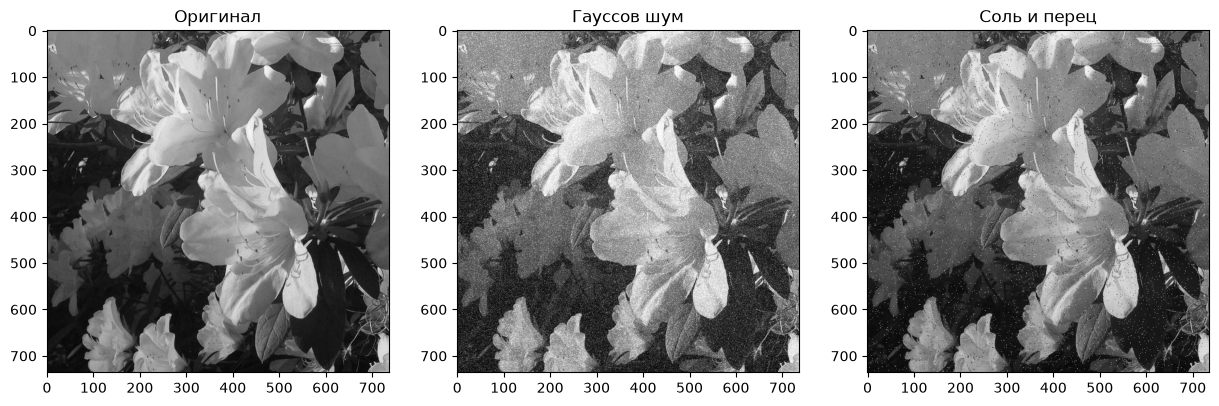

In [7]:
image = cv2.imread('flowers.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

mean = 0
stddev = 50 
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

noise_sp_mask = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
image_sp = image_gray.copy()
image_sp[noise_sp_mask == 0] = 0    
image_sp[noise_sp_mask == 100] = 255 

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(1, 3, 2), plt.imshow(image_noise_gauss, cmap='gray'), plt.title('Гауссов шум')
plt.subplot(1, 3, 3), plt.imshow(image_sp, cmap='gray'), plt.title('Соль и перец')
plt.show()

In [8]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse
def evaluate_filter(original, filtered, name):
    mse_val = mse(original, filtered)
    ssim_val = ssim(original, filtered)
    print(f"{name}: MSE = {mse_val:.2f}, SSIM = {ssim_val:.4f}")
    return mse_val, ssim_val
print("--- Результаты для Гауссова шума ---")

median_gauss = cv2.medianBlur(image_noise_gauss, 5)
evaluate_filter(image_gray, median_gauss, "Медианный (k=5)")

gaussian_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
evaluate_filter(image_gray, gaussian_gauss, "Гауссов (5x5)")

bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
evaluate_filter(image_gray, bilateral_gauss, "Билатеральный (d=9)")

nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, None, h=10, templateWindowSize=7, searchWindowSize=21)
evaluate_filter(image_gray, nlm_gauss, "NLM (h=10)")

print("\n--- Результаты для шума 'Соль и перец' ---")

median_sp = cv2.medianBlur(image_sp, 5)
evaluate_filter(image_gray, median_sp, "Медианный (k=5)")

gaussian_sp = cv2.GaussianBlur(image_sp, (5, 5), 0)
evaluate_filter(image_gray, gaussian_sp, "Гауссов (5x5)")

bilateral_sp = cv2.bilateralFilter(image_sp, 9, 75, 75)
evaluate_filter(image_gray, bilateral_sp, "Билатеральный (d=9)")

nlm_sp = cv2.fastNlMeansDenoising(image_sp, None, h=10, templateWindowSize=7, searchWindowSize=21)
evaluate_filter(image_gray, nlm_sp, "NLM (h=10)")

--- Результаты для Гауссова шума ---
Медианный (k=5): MSE = 202.83, SSIM = 0.6881
Гауссов (5x5): MSE = 479.23, SSIM = 0.6477
Билатеральный (d=9): MSE = 415.24, SSIM = 0.6751
NLM (h=10): MSE = 1151.84, SSIM = 0.2588

--- Результаты для шума 'Соль и перец' ---
Медианный (k=5): MSE = 57.96, SSIM = 0.8921
Гауссов (5x5): MSE = 75.29, SSIM = 0.7951
Билатеральный (d=9): MSE = 183.61, SSIM = 0.6966
NLM (h=10): MSE = 377.47, SSIM = 0.6291


(np.float64(377.46694455931004), np.float64(0.6291032506278779))

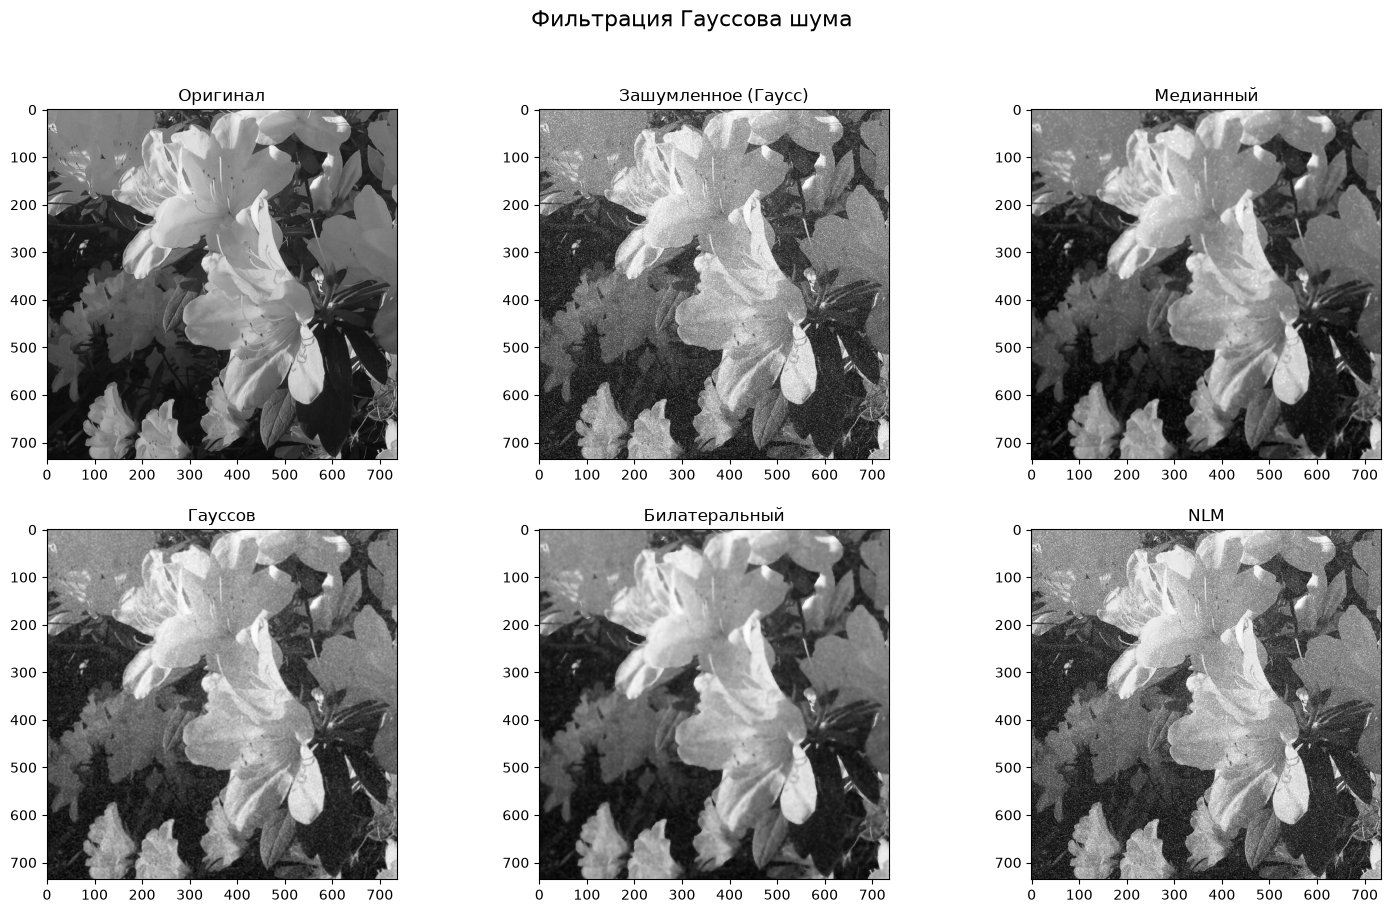

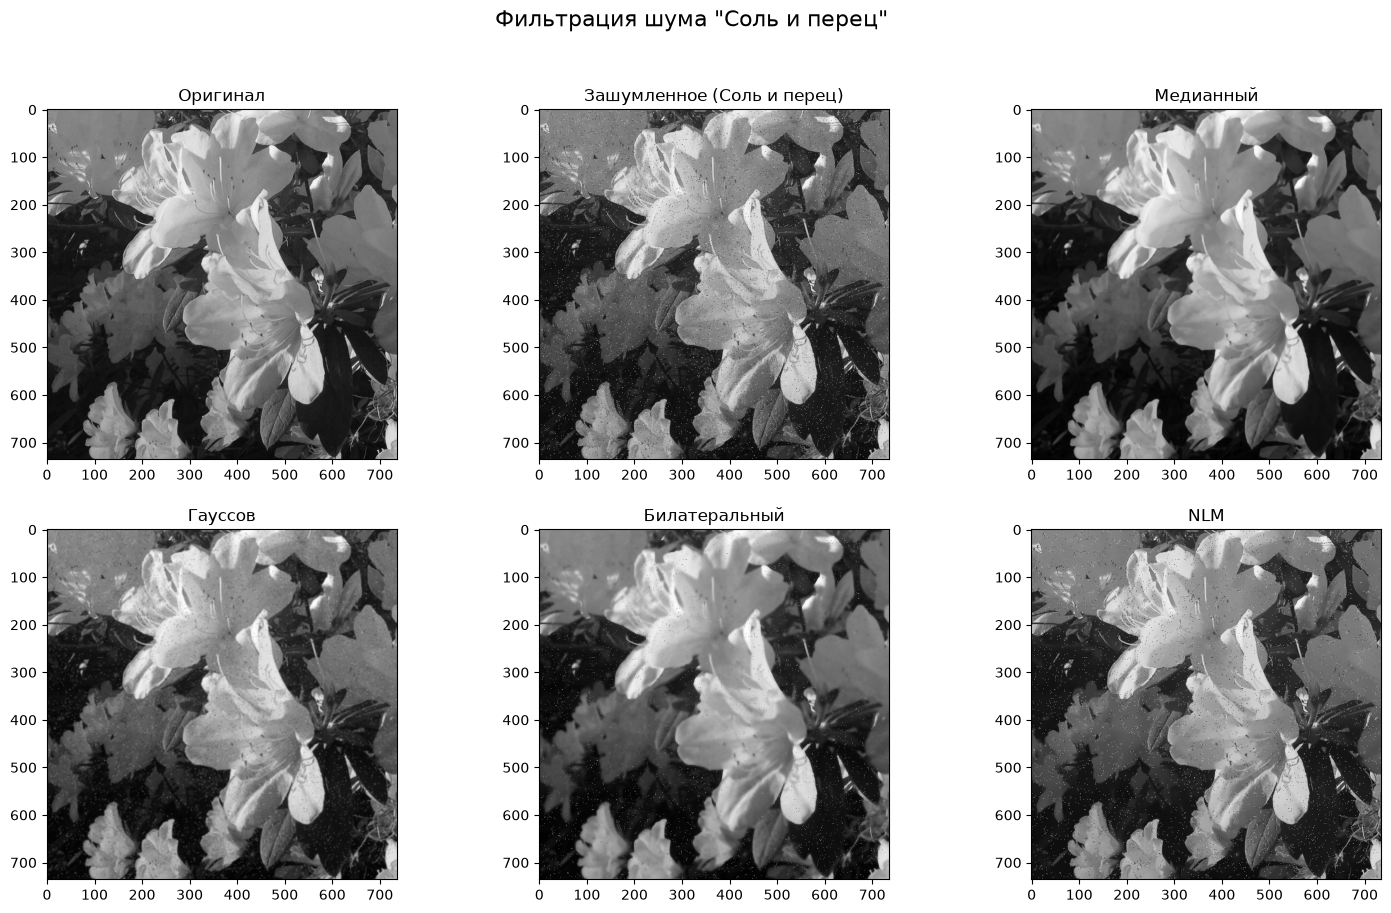

In [9]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(2, 3, 2), plt.imshow(image_noise_gauss, cmap='gray'), plt.title('Зашумленное (Гаусс)')
plt.subplot(2, 3, 3), plt.imshow(median_gauss, cmap='gray'), plt.title('Медианный')
plt.subplot(2, 3, 4), plt.imshow(gaussian_gauss, cmap='gray'), plt.title('Гауссов')
plt.subplot(2, 3, 5), plt.imshow(bilateral_gauss, cmap='gray'), plt.title('Билатеральный')
plt.subplot(2, 3, 6), plt.imshow(nlm_gauss, cmap='gray'), plt.title('NLM')
plt.suptitle('Фильтрация Гауссова шума', fontsize=16)
plt.show()

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1), plt.imshow(image_gray, cmap='gray'), plt.title('Оригинал')
plt.subplot(2, 3, 2), plt.imshow(image_sp, cmap='gray'), plt.title('Зашумленное (Соль и перец)')
plt.subplot(2, 3, 3), plt.imshow(median_sp, cmap='gray'), plt.title('Медианный')
plt.subplot(2, 3, 4), plt.imshow(gaussian_sp, cmap='gray'), plt.title('Гауссов')
plt.subplot(2, 3, 5), plt.imshow(bilateral_sp, cmap='gray'), plt.title('Билатеральный')
plt.subplot(2, 3, 6), plt.imshow(nlm_sp, cmap='gray'), plt.title('NLM')
plt.suptitle('Фильтрация шума "Соль и перец"', fontsize=16)
plt.show()

In [10]:
#по метрикам и при визуальном осмотре лучший результат показал медианный фильтр